# Table-tap transient analysis

This notebook explores transient vibration caused by table taps, including centering, RMS, peak-to-peak range, and clipping checks. It helps validate behavior outside the controlled training conditions.

> Keep reusable calculations in `src/machine_sentinel/features.py`; this notebook is for interactive inspection and plots.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../../data/raw/table_taps.csv')

In [3]:
df.head(5)

,timestamp_us,ax,ay,az,time_s
0,711501,290,36,4882,NaN
1,716436,291,32,4860,NaN
2,721436,286,38,4864,NaN
3,726437,299,13,4880,NaN
4,731438,301,44,4872,NaN


In [4]:
df['time_s'] = (df['timestamp_us'] - df['timestamp_us'].iloc[0]) / 1e6

In [5]:
accl_z = df['az']
time = df['time_s']

In [6]:
mean = np.mean(accl_z)
std = np.std(accl_z)
ptp = np.ptp(accl_z)
rms = np.sqrt(np.mean(np.square(accl_z)))

In [7]:
print(f"Mean: {mean}")
print(f"Standard Deviation: {std}")
print(f"Peak-to-Peak: {ptp}")
print(f"RMS: {rms}")

Mean: 4871.02600374454
Standard Deviation: 938.2597484018435
Peak-to-Peak: 28310
RMS: 4960.567072888602


In [8]:
z_centered = accl_z - mean

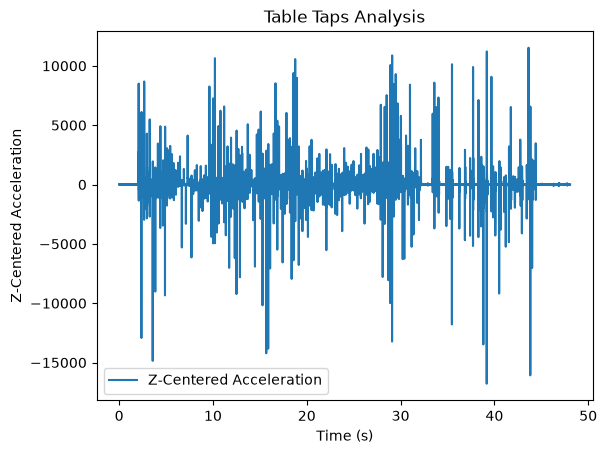

In [9]:
plt.plot(time, z_centered, label='Z-Centered Acceleration')
plt.xlabel('Time (s)')
plt.ylabel('Z-Centered Acceleration')
plt.title('Table Taps Analysis')
plt.legend()
plt.show()

In [10]:
rms_z_centered = np.sqrt(np.mean(np.square(z_centered)))
print(f"RMS of Z-Centered Acceleration: {rms_z_centered}")

mean_z_centered = np.mean(z_centered)
print(f"Mean of Z-Centered Acceleration: {mean_z_centered}")

std_z_centered = np.std(z_centered)
print(f"Standard Deviation of Z-Centered Acceleration: {std_z_centered}")

ptp_z_centered = np.ptp(z_centered)
print(f"Peak-to-Peak of Z-Centered Acceleration: {ptp_z_centered}")

RMS of Z-Centered Acceleration: 938.2597484018435
Mean of Z-Centered Acceleration: -3.961892876040174e-13
Standard Deviation of Z-Centered Acceleration: 938.2597484018435
Peak-to-Peak of Z-Centered Acceleration: 28310.0


In [11]:
print("Minimum:", df["az"].min())
print("Maximum:", df["az"].max())

print("At minimum:",
      (df["az"] == -32768).sum())

print("At maximum:",
      (df["az"] == 32767).sum())

Minimum: -11910
Maximum: 16400
At minimum: 0
At maximum: 0


In [12]:
clipped = (df["az"] == 32767) | (df["az"] == -32768)

print("Clipped samples:", clipped.sum())
print("Clipped percentage:", clipped.mean() * 100)

Clipped samples: 0
Clipped percentage: 0.0


In [13]:
import pandas as pd
import numpy as np

SAMPLE_RATE = 200
WINDOW_SIZE = 200       # 1 second
COUNTS_PER_G = 4096.0   # MPU6050 at ±8g


def extract_features(df, experiment, label=None):

    features = []

    for start in range(0, len(df), WINDOW_SIZE):

        end = start + WINDOW_SIZE

        # Ignore incomplete final window
        if end > len(df):
            break

        window = df.iloc[start:end]

        # Convert raw Z-axis counts -> g
        z_g = window["az"] / COUNTS_PER_G

        # Remove gravity / DC component
        z_centered = z_g - z_g.mean()

        # Time-domain features
        rms = np.sqrt(np.mean(np.square(z_centered)))

        # ddof=0 so STD matches centered RMS mathematically
        std = z_centered.std(ddof=0)

        peak_to_peak = z_g.max() - z_g.min()

        features.append({
            "start_idx": start,
            "end_idx": end,
            "start_time_s": start / SAMPLE_RATE,

            "rms": rms,
            "std": std,
            "ptp": peak_to_peak,

            "experiment": experiment,
            "label": label
        })

    return pd.DataFrame(features)

In [14]:
tap_features = extract_features(
    df,
    experiment="tap_test",
    label=None
)

print(tap_features)

    start_idx  end_idx  start_time_s       rms       std       ptp experiment  \
0           0      200           0.0  0.003584  0.003584  0.023682   tap_test   
1         200      400           1.0  0.003993  0.003993  0.020508   tap_test   
2         400      600           2.0  0.356195  0.356195  5.276123   tap_test   
3         600      800           3.0  0.330902  0.330902  4.966797   tap_test   
4         800     1000           4.0  0.244087  0.244087  3.479492   tap_test   
5        1000     1200           5.0  0.145015  0.145015  1.226318   tap_test   
6        1200     1400           6.0  0.118928  0.118928  1.874756   tap_test   
7        1400     1600           7.0  0.145731  0.145731  2.506592   tap_test   
8        1600     1800           8.0  0.090204  0.090204  1.146973   tap_test   
9        1800     2000           9.0  0.184245  0.184245  3.092773   tap_test   
10       2000     2200          10.0  0.315806  0.315806  3.809326   tap_test   
11       2200     2400      